# BANKRUPTCY PREDICTION - Model Building and Evaluation

train 7 classifiers, run cross-validation ,plot ROC-curve, tune the best performer with `GridSearchCV`

## 1. Import and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score,precision_score
                            , recall_score, f1_score, confusion_matrix,
                            roc_curve, auc, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from utils import *

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('data\cleaned_bankrupty.csv')
print(df.shape)
df.head()

(6819, 98)


,Bankrupt,ROA_C_Before_Interest_Depreciation,ROA_A_Before_Interest_After_Tax,ROA_B_Before_Interest_Depreciation_After_Tax,Operating_Gross_Margin,Realized_Sales_Gross_Margin,Operating_Profit_Rate,PreTax_Net_Interest_Rate,AfterTax_Net_Interest_Rate,NonIndustry_Income_Expenditure_Revenue,...,NoCredit_Interval,Gross_Profit_to_Sales,Net_Income_to_Stockholders_Equity,Liability_to_Equity,DFL,Interest_Coverage_Ratio,Equity_to_Liability,Profitability,Leverage,liquidity
0,0,0.571832,0.642390,0.634670,0.626169,0.626169,0.999232,0.797749,0.809653,0.303602,...,0.623980,0.626165,0.843256,0.275994,0.026797,0.565185,0.083956,0.616297,2.163525e-01,2.891064e-01
1,0,0.494613,0.549771,0.543445,0.602091,0.602091,0.998986,0.797405,0.809328,0.303516,...,0.623701,0.602091,0.840783,0.281189,0.027200,0.566564,0.025107,0.529276,1.836842e+08,3.250000e+08
2,0,0.465315,0.515645,0.511591,0.593782,0.593782,0.998961,0.797354,0.809277,0.303480,...,0.623801,0.593777,0.839341,0.278153,0.026630,0.564252,0.038119,0.497517,2.007148e-01,2.966667e+08
3,0,0.506118,0.556912,0.547727,0.615820,0.615820,0.999169,0.797528,0.809401,0.303348,...,0.623844,0.615818,0.840996,0.277714,0.026863,0.565477,0.042154,0.536919,1.923942e-01,2.828956e-01
4,0,0.539170,0.593273,0.586273,0.606949,0.606949,0.999077,0.797485,0.809394,0.303465,...,0.623774,0.606948,0.842516,0.279316,0.026818,0.565285,0.031117,0.572906,2.198472e-01,5.433333e+08


## 2. Split the data to train and test with confirmation

In [3]:
X = df.drop(columns='Bankrupt')
y = df['Bankrupt']

X_train, X_, y_train, y_ = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)
X_test , X_safe, y_test, y_safe = train_test_split(X_, y_, random_state=42, train_size=0.8, )

In [4]:
print(f'X_train shape : {X_train.shape}, X_test shape: {X_test.shape}, X_safe shape: {X_safe.shape}')
print(f'y_train shape : {y_train.shape}, y_test shape: {y_test.shape}, y_safe shape: {y_safe.shape}')

X_train shape : (5455, 97), X_test shape: (1091, 97), X_safe shape: (273, 97)
y_train shape : (5455,), y_test shape: (1091,), y_safe shape: (273,)


# Model Building - Using Pipeline

In [5]:
models = {
    'Logistic Regression' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, ))
    ]), 
    
    'Decision Tree' : Pipeline([
        ('model', DecisionTreeClassifier(max_depth=3, random_state=42))
    ]),
    
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(random_state=42, n_estimators=250, max_depth= 4))
    ]),
    
    'Gradient Boosting' : Pipeline([
        ('model', GradientBoostingClassifier(learning_rate=0.01, n_estimators=300, max_depth=4, random_state=42))
    ]),
    
    'KNN' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors= 5))
    ]),
    
    'SVC' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='poly', probability=True, C=2))
    ]),
    
    'GaussianNB' : Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
}

____________________________________________________________ REPORT ON -- Logistic Regression________________________________________________________________________________
Metric of Logistic Regression:

Accuracy   97.159%
Precision  55.000%
Recall     33.333%
F1 Score   41.509%
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99      1058
    Bankrupt       0.55      0.33      0.42        33

    accuracy                           0.97      1091
   macro avg       0.76      0.66      0.70      1091
weighted avg       0.97      0.97      0.97      1091



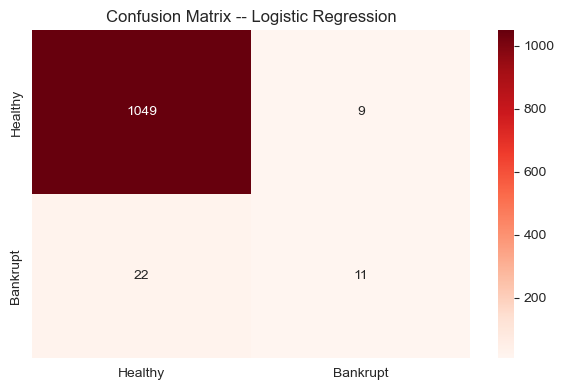

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- Decision Tree________________________________________________________________________________
Metric of Decision Tree:

Accuracy   96.700%
Precision  42.105%
Recall     24.242%
F1 Score   30.769%
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.98      1058
    Bankrupt       0.42      0.24      0.31        33

    accuracy                           0.97      1091
   macro avg       0.70      0.62      0.65      1091
weighted avg       0.96      0.97      0.96      1091



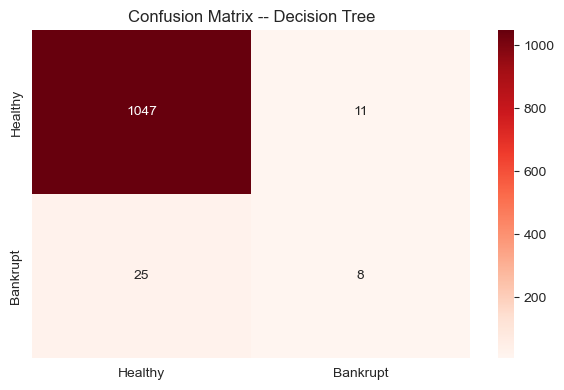

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- Random Forest________________________________________________________________________________
Metric of Random Forest:

Accuracy   97.250%
Precision  80.000%
Recall     12.121%
F1 Score   21.053%
              precision    recall  f1-score   support

     Healthy       0.97      1.00      0.99      1058
    Bankrupt       0.80      0.12      0.21        33

    accuracy                           0.97      1091
   macro avg       0.89      0.56      0.60      1091
weighted avg       0.97      0.97      0.96      1091



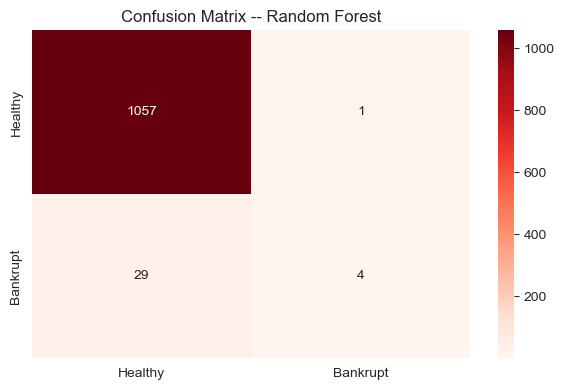

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- Gradient Boosting________________________________________________________________________________
Metric of Gradient Boosting:

Accuracy   97.250%
Precision  61.538%
Recall     24.242%
F1 Score   34.783%
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99      1058
    Bankrupt       0.62      0.24      0.35        33

    accuracy                           0.97      1091
   macro avg       0.80      0.62      0.67      1091
weighted avg       0.97      0.97      0.97      1091



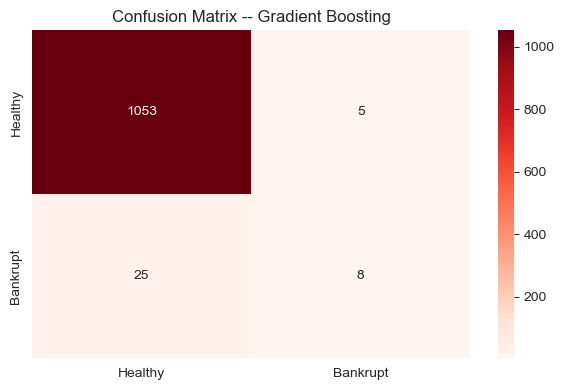

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- KNN________________________________________________________________________________
Metric of KNN:

Accuracy   97.067%
Precision  53.846%
Recall     21.212%
F1 Score   30.435%
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99      1058
    Bankrupt       0.54      0.21      0.30        33

    accuracy                           0.97      1091
   macro avg       0.76      0.60      0.64      1091
weighted avg       0.96      0.97      0.96      1091



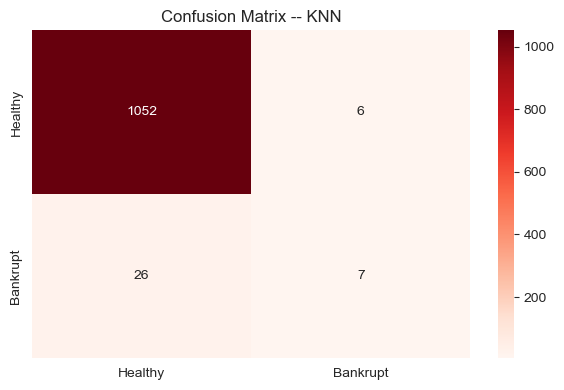

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- SVC________________________________________________________________________________
Metric of SVC:

Accuracy   96.059%
Precision  30.769%
Recall     24.242%
F1 Score   27.119%
              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98      1058
    Bankrupt       0.31      0.24      0.27        33

    accuracy                           0.96      1091
   macro avg       0.64      0.61      0.63      1091
weighted avg       0.96      0.96      0.96      1091



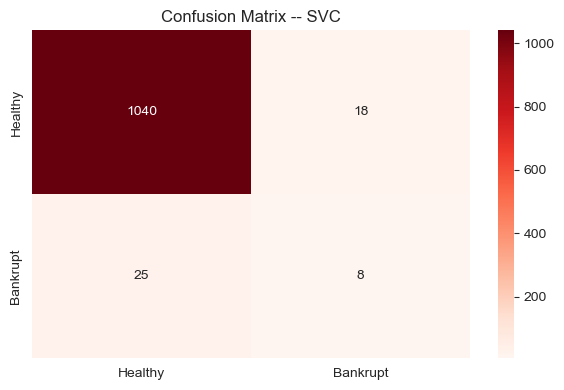

________________________________________________________________________________________________________________________________________________________________
____________________________________________________________ REPORT ON -- GaussianNB________________________________________________________________________________
Metric of GaussianNB:

Accuracy   87.168%
Precision  17.178%
Recall     84.848%
F1 Score   28.571%
              precision    recall  f1-score   support

     Healthy       0.99      0.87      0.93      1058
    Bankrupt       0.17      0.85      0.29        33

    accuracy                           0.87      1091
   macro avg       0.58      0.86      0.61      1091
weighted avg       0.97      0.87      0.91      1091



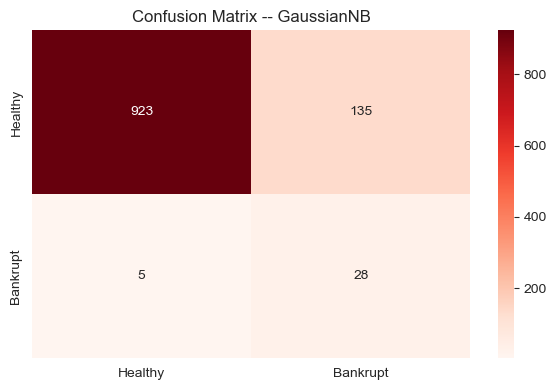

________________________________________________________________________________________________________________________________________________________________


In [7]:
results = []

for model_name, estimators in models.items():
    estimators.fit(X_train, y_train)
    est_pred = estimators.predict(X_test)
    print(f"{'__'*30} REPORT ON -- {model_name}{'__'*40}")
    
    metric= evaluate_metric(y_test, y_pred= est_pred, model_name= model_name)
    results.append(metric)
    
    print(classification_report(y_test, y_pred= est_pred, target_names =  target_label))
    plot(y_test, y_pred= est_pred, model_name= model_name)
    
    print("__"*80)
    
    

# Finding the best K- value

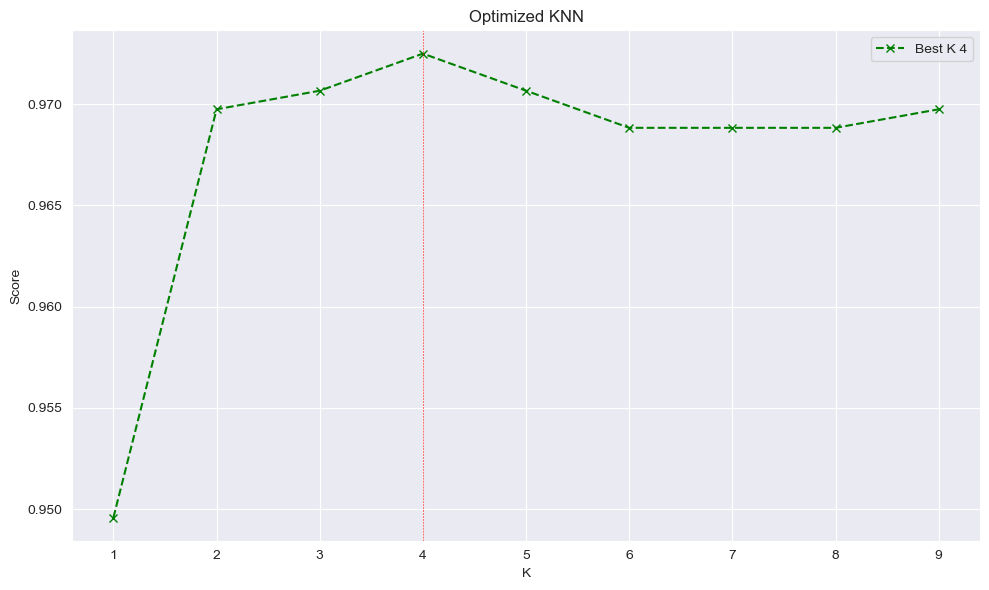

In [8]:
score = []
K = list(range(1, 10))

for k in K:
    temp_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=k))])
    
    temp_knn.fit(X_train, y_train)
    knn_pred = temp_knn.predict(X_test)
    
    score.append(accuracy_score(y_test, knn_pred, ))

best_k = K[np.argmax(score)]
fig, ax = plt.subplots(figsize= (10, 6))
ax.plot(K , score, marker='x',linestyle= '--', color='green', label= f"Best K {best_k}")
ax.axvline(best_k, linestyle= '--', color='red', linewidth= 0.4)
ax.set_xlabel("K"); ax.set_ylabel("Score")
ax.set_title("Optimized KNN")
ax.legend()

plt.tight_layout();     plt.show()

____________________________________________________________ REPORT ON -- Optimized KNN________________________________________________________________________________
Metric of Optimized KNN:

Accuracy   97.250%
Precision  63.636%
Recall     21.212%
F1 Score   31.818%
              precision    recall  f1-score   support

     Healthy       0.98      1.00      0.99      1058
    Bankrupt       0.64      0.21      0.32        33

    accuracy                           0.97      1091
   macro avg       0.81      0.60      0.65      1091
weighted avg       0.97      0.97      0.97      1091



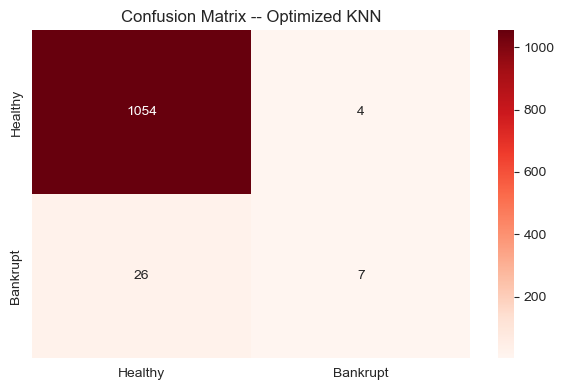

________________________________________________________________________________________________________________________________________________________________


In [9]:
models['Optimized KNN'] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=best_k))])

for model_name, estimators in models.items():
        if model_name == 'Optimized KNN':
                estimators.fit(X_train, y_train)
                est_pred = estimators.predict(X_test)
                print(f"{'__'*30} REPORT ON -- {model_name}{'__'*40}")
                
                metric= evaluate_metric(y_test, y_pred= est_pred, model_name= model_name)
                results.append(metric)
                
                print(classification_report(y_test, y_pred= est_pred, target_names =  target_label))
                plot(y_test, y_pred= est_pred, model_name= model_name)
                
                print("__"*80)

## Model Comparism

In [10]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df
results_df.style.background_gradient(cmap='Blues')

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.972502,0.800000,0.121212,0.210526
1,Gradient Boosting,0.972502,0.615385,0.242424,0.347826
2,Optimized KNN,0.972502,0.636364,0.212121,0.318182
3,Logistic Regression,0.971586,0.550000,0.333333,0.415094
4,KNN,0.970669,0.538462,0.212121,0.304348
5,Decision Tree,0.967003,0.421053,0.242424,0.307692
6,SVC,0.960587,0.307692,0.242424,0.271186
7,GaussianNB,0.871677,0.171779,0.848485,0.285714


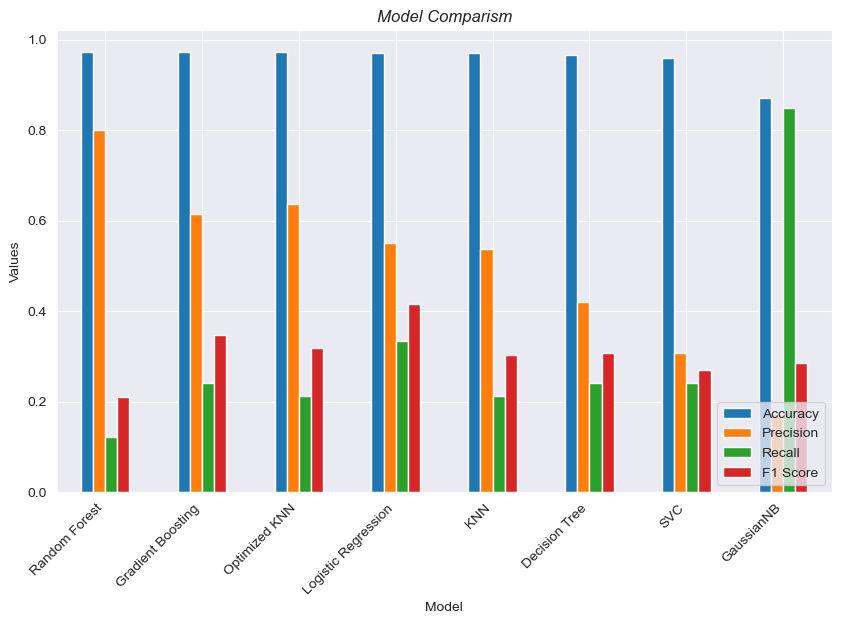

In [14]:
from matplotlib.pyplot import gca
ax = gca()
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(kind='bar',ax= ax)
ax.set_ylabel("Values")        ; ax.set_title("Model Comparism", fontweight=30, fontstyle='oblique');  plt.xticks( rotation=45, ha='right')
ax.set_aspect('auto')
ax.legend(loc='lower right')

plt.show()

## Feature Importance - Tree based and others

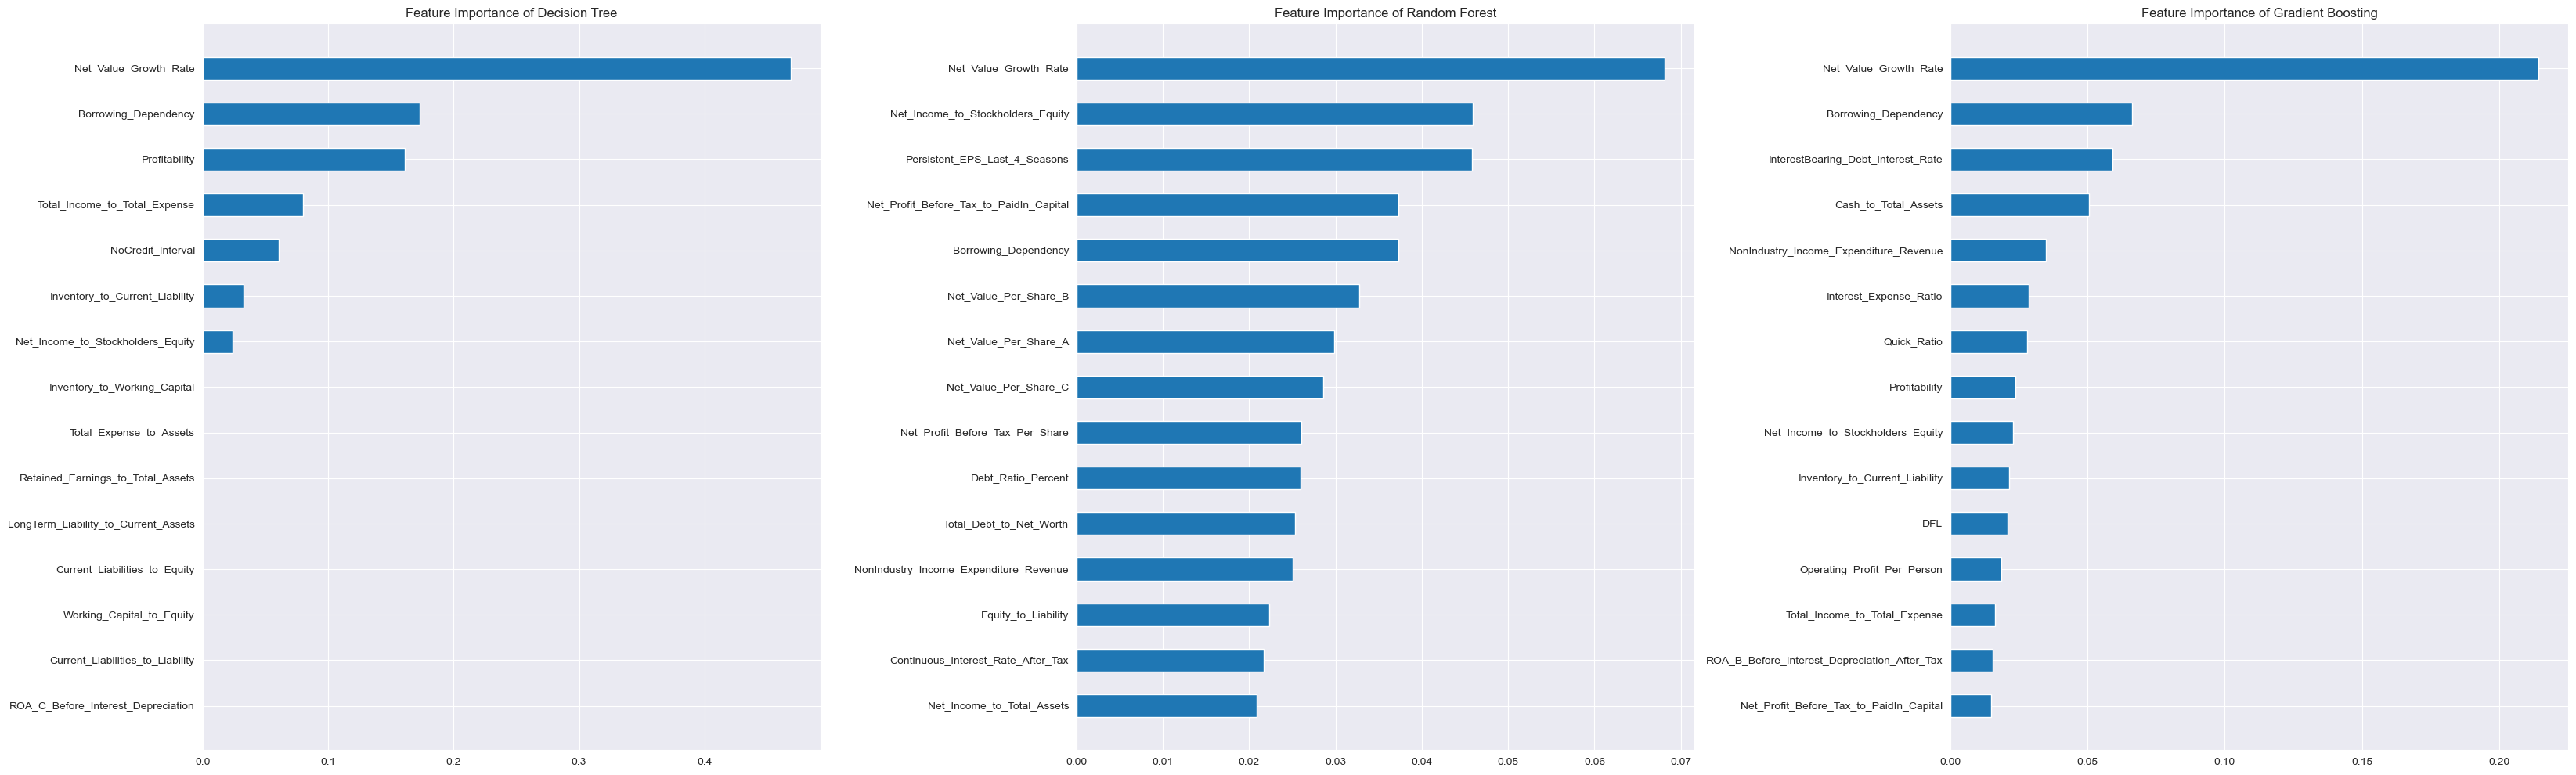

In [49]:
fig, axes = plt.subplots(1, 3 , figsize= (33, 10))
axes = axes.flatten()


for axes, (name, est) in zip(axes, [(a,b) 
                                    for a,b in models.items() 
                                    if a in ['Random Forest', 'Decision Tree', 'Gradient Boosting']]):
    
    model = est.named_steps['model']

    imp = pd.Series(model.feature_importances_, index= X.columns).sort_values(ascending= False)[:15]
    axes.barh(imp.index, imp.values, height= 0.5)
    axes.invert_yaxis()
    axes.set_title(f"Feature Importance of {name}")
        
plt.tight_layout();     plt.show()

## 5-Fold Cross-Validation 

In [69]:

def cross_v_score(est, X_test, y_test,):
    score = cross_val_score(
        est,
        X_test,
        y_test,
        cv= 3,
        scoring= 'accuracy'
    )
    
    print(f"CV Accuracy: {score.round(4)}")
    print(f"CV Mean score: {score.mean():.4f}, (+/- {score.std():.4f})")
    
    return score

In [70]:
cv_score = {}

for name, est in models.items():
    print("")
    score = cross_v_score(est= est, X_test =X_test, y_test=y_test)
    cv_score[name] = score
    print(f"{name:<25} , Mean Accuracy: {score.mean():.4f}, (+/- {score.std():.4f}")
    print('')



CV Accuracy: [0.9643 0.9698 0.9587]
CV Mean score: 0.9642, (+/- 0.0045)
Logistic Regression       , Mean Accuracy: 0.9642, (+/- 0.0045


CV Accuracy: [0.9643 0.9698 0.9477]
CV Mean score: 0.9606, (+/- 0.0094)
Decision Tree             , Mean Accuracy: 0.9606, (+/- 0.0094


CV Accuracy: [0.9615 0.9808 0.9725]
CV Mean score: 0.9716, (+/- 0.0079)
Random Forest             , Mean Accuracy: 0.9716, (+/- 0.0079


CV Accuracy: [0.967  0.9808 0.9587]
CV Mean score: 0.9688, (+/- 0.0091)
Gradient Boosting         , Mean Accuracy: 0.9688, (+/- 0.0091


CV Accuracy: [0.9698 0.978  0.9697]
CV Mean score: 0.9725, (+/- 0.0039)
KNN                       , Mean Accuracy: 0.9725, (+/- 0.0039


CV Accuracy: [0.9615 0.9698 0.9614]
CV Mean score: 0.9643, (+/- 0.0039)
SVC                       , Mean Accuracy: 0.9643, (+/- 0.0039


CV Accuracy: [0.8379 0.7445 0.7961]
CV Mean score: 0.7929, (+/- 0.0382)
GaussianNB                , Mean Accuracy: 0.7929, (+/- 0.0382


CV Accuracy: [0.9698 0.9725 0.9725]
CV M